# Feature Importance Analysis
## Bangladesh Community Health Screening Dataset

This notebook applies **5 complementary feature importance methods** to identify which demographic and clinical features best predict hypertension (`profile_hypertensive`):

| # | Method | Type | Why use it |
|---|--------|------|-----------|
| 1 | Pearson Correlation | Statistical | Linear relationships, quick baseline |
| 2 | Point-Biserial + Cramér's V | Statistical | Binary/categorical target correlations |
| 3 | Random Forest Importance (MDI) | Tree-based | Captures non-linear effects |
| 4 | Permutation Importance | Model-agnostic | Corrects RF bias toward high-cardinality features |
| 5 | Boruta | Wrapper (RF-based) | Confirms/rejects each feature against random shadows |

**Target variable:** `profile_hypertensive` (binary: 0 = no, 1 = yes; 1,575 positive cases / 28,236 negative)


In [3]:
pip install boruta


Note: you may need to restart the kernel to use updated packages.


## 1. Setup & Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils import resample

from boruta import BorutaPy
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries loaded.')


All libraries loaded.


In [5]:
# ── Load & preprocess ──────────────────────────────────────────────────────
df_raw = pd.read_excel('test-dataset.xlsx')
df = df_raw.copy()

# Fix birthday → recompute age
df['birthday'] = pd.to_datetime(df['birthday'], errors='coerce').dt.normalize()
REFERENCE_DATE = pd.Timestamp('2020-01-01')
df['age'] = ((REFERENCE_DATE - df['birthday']).dt.days / 365.25).round()
df = df[(df['age'] > 0) & (df['age'] <= 100)].copy()

# Clip clinical vitals to plausible ranges
clips = {
    'SYSTOLIC':   (60,  220),
    'DIASTOLIC':  (40,  130),
    'PULSE_RATE': (30,  200),
    'SPO2':       (70,  100),
}
for col, (lo, hi) in clips.items():
    df[col] = df[col].clip(lo, hi)

# Encode categoricals
income_map = {'Lower class': 0, 'Lower-middle class': 1, 'Middle class': 2, 'Upper class': 3}
df['income_enc']       = df['total_income'].map(income_map)
df['gender_enc']       = (df['gender'] == 'Female').astype(int)
df['diabetic_enc']     = df['diabetic'].astype(int)
df['hypertensive_enc'] = df['profile_hypertensive'].astype(int)

# Impute moderate-missingness vitals (BP, pulse ~8%) with gender-stratified median
for col in ['SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE']:
    medians = df.groupby('gender')[col].median()
    for g, m in medians.items():
        df.loc[(df['gender'] == g) & df[col].isnull(), col] = m
    df[col] = df[col].fillna(df[col].median())

# Final feature set (columns available for >90% of rows)
FEATURES = [
    'age', 'gender_enc', 'income_enc',
    'SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE',
    'diabetic_enc', 'had_stroke', 'has_cardiovascular_disease',
    'is_freedom_fighter'
]
FEATURE_LABELS = [
    'Age', 'Gender (F=1)', 'Income level',
    'Systolic BP', 'Diastolic BP', 'Pulse rate',
    'Diabetic', 'Had stroke', 'Cardiovascular disease',
    'Freedom fighter'
]
TARGET = 'hypertensive_enc'

df_model = df[FEATURES + [TARGET]].dropna().copy()

print(f'Modelling dataset: {df_model.shape[0]:,} rows × {len(FEATURES)} features')
print(f'Target balance — 0: {(df_model[TARGET]==0).sum():,}  |  1: {(df_model[TARGET]==1).sum():,}')
print(f'Positive rate: {df_model[TARGET].mean()*100:.2f}%')


Modelling dataset: 29,811 rows × 10 features
Target balance — 0: 28,236  |  1: 1,575
Positive rate: 5.28%


In [6]:
# ── Balanced dataset for ML methods (oversample minority class) ──────────────
df_maj = df_model[df_model[TARGET] == 0]
df_min = df_model[df_model[TARGET] == 1]

df_min_up = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
df_balanced = pd.concat([df_maj, df_min_up]).sample(frac=1, random_state=42)

X_bal = df_balanced[FEATURES].values
y_bal = df_balanced[TARGET].values

X_all = df_model[FEATURES].values
y_all = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

print(f'Balanced train: {X_train.shape}  |  test: {X_test.shape}')


Balanced train: (45177, 10)  |  test: (11295, 10)


---
## 2. Pearson Correlation

Measures **linear** association between each numeric feature and the binary target.  
- Range: −1 to +1  
- Positive → feature increases with hypertension probability  
- **Limitation:** only detects linear effects; misses non-linear patterns


In [7]:
pearson_results = []
for feat, label in zip(FEATURES, FEATURE_LABELS):
    r, p = stats.pearsonr(df_model[feat], df_model[TARGET])
    pearson_results.append({'Feature': label, 'Pearson_r': r, 'p_value': p,
                            'abs_r': abs(r), 'significant': p < 0.05})

pearson_df = pd.DataFrame(pearson_results).sort_values('abs_r', ascending=False)
print(pearson_df[['Feature', 'Pearson_r', 'p_value', 'significant']].to_string(index=False))


               Feature  Pearson_r  p_value  significant
              Diabetic     0.3385   0.0000         True
                   Age     0.2144   0.0000         True
           Systolic BP     0.1971   0.0000         True
          Diastolic BP     0.1256   0.0000         True
            Had stroke     0.0906   0.0000         True
Cardiovascular disease     0.0898   0.0000         True
            Pulse rate    -0.0464   0.0000         True
          Gender (F=1)     0.0084   0.1450        False
       Freedom fighter     0.0072   0.2126        False
          Income level    -0.0025   0.6630        False


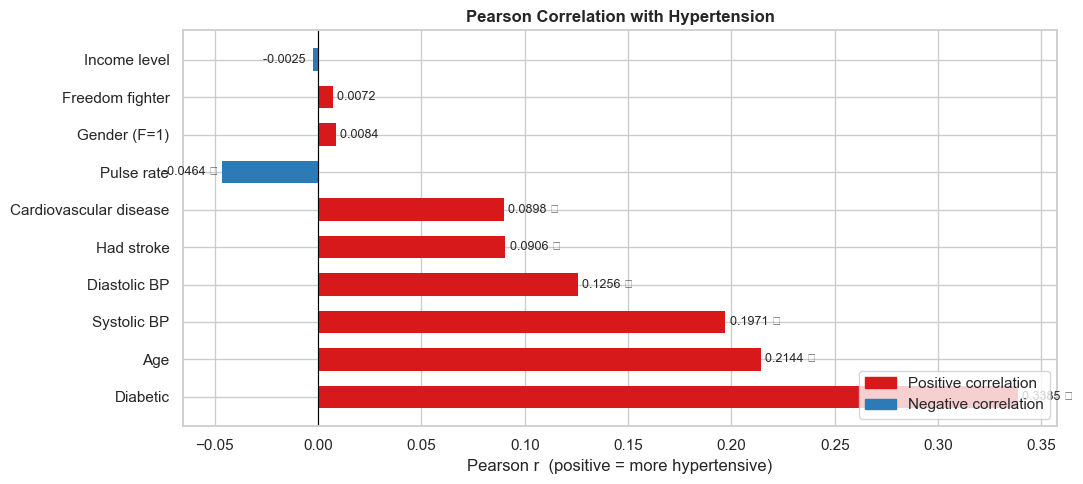

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d7191c' if r > 0 else '#2c7bb6' for r in pearson_df['Pearson_r']]
bars = ax.barh(pearson_df['Feature'], pearson_df['Pearson_r'], color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r  (positive = more hypertensive)')
ax.set_title('Pearson Correlation with Hypertension')

for bar, (_, row) in zip(bars, pearson_df.iterrows()):
    sig = '★' if row['significant'] else ''
    ax.text(bar.get_width() + (0.002 if bar.get_width() >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{row["Pearson_r"]:.4f} {sig}', va='center', fontsize=9,
            ha='left' if bar.get_width() >= 0 else 'right')

red_patch  = mpatches.Patch(color='#d7191c', label='Positive correlation')
blue_patch = mpatches.Patch(color='#2c7bb6', label='Negative correlation')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')
plt.tight_layout()
plt.show()


---
## 3. Point-Biserial Correlation & Cramér's V

**Point-Biserial** is the correct correlation for continuous feature vs binary target (mathematically equivalent to Pearson but explicitly designed for this case).  
**Cramér's V** is used for categorical vs categorical association (chi-squared based).


In [9]:
# Point-Biserial for continuous features
continuous_feats = ['age', 'SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE', 'income_enc']
cont_labels      = ['Age', 'Systolic BP', 'Diastolic BP', 'Pulse rate', 'Income level']

pb_results = []
for feat, label in zip(continuous_feats, cont_labels):
    r, p = pointbiserialr(df_model[TARGET], df_model[feat])
    pb_results.append({'Feature': label, 'Point_Biserial_r': round(r, 5),
                       'p_value': round(p, 6), 'significant': p < 0.05})

pb_df = pd.DataFrame(pb_results).sort_values('Point_Biserial_r', key=abs, ascending=False)
print('=== Point-Biserial Correlation ===')
print(pb_df.to_string(index=False))


=== Point-Biserial Correlation ===
     Feature  Point_Biserial_r  p_value  significant
         Age            0.2144   0.0000         True
 Systolic BP            0.1971   0.0000         True
Diastolic BP            0.1256   0.0000         True
  Pulse rate           -0.0464   0.0000         True
Income level           -0.0025   0.6630        False


In [10]:
# Cramér's V for binary/categorical features vs target
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

cat_feats  = ['gender_enc', 'diabetic_enc', 'had_stroke',
              'has_cardiovascular_disease', 'is_freedom_fighter']
cat_labels = ["Gender", "Diabetic", "Had stroke",
              "Cardiovascular disease", "Freedom fighter"]

cv_results = []
for feat, label in zip(cat_feats, cat_labels):
    v = cramers_v(df_model[feat], df_model[TARGET])
    cv_results.append({'Feature': label, "Cramér's V": round(v, 5)})

cv_df = pd.DataFrame(cv_results).sort_values("Cramér's V", ascending=False)
print("\n=== Cramér's V (categorical features) ===")
print(cv_df.to_string(index=False))



=== Cramér's V (categorical features) ===
               Feature  Cramér's V
              Diabetic      0.3379
            Had stroke      0.0878
Cardiovascular disease      0.0873
                Gender      0.0059
       Freedom fighter      0.0000


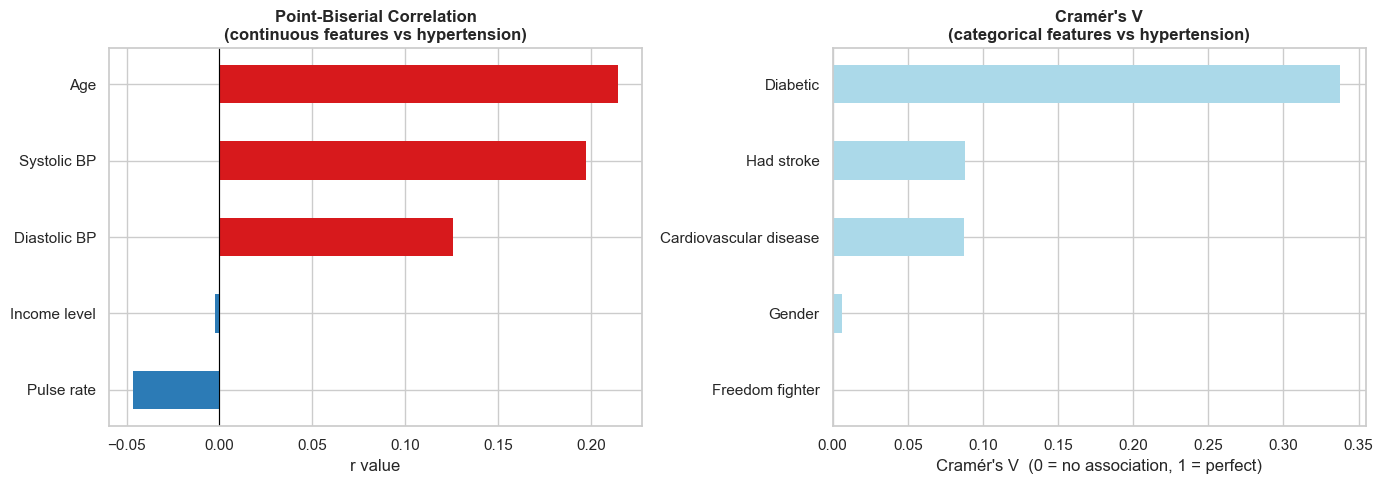

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Point-Biserial
pb_sorted = pb_df.sort_values('Point_Biserial_r')
colors_pb = ['#d7191c' if r > 0 else '#2c7bb6' for r in pb_sorted['Point_Biserial_r']]
ax1.barh(pb_sorted['Feature'], pb_sorted['Point_Biserial_r'], color=colors_pb, edgecolor='none', height=0.5)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title("Point-Biserial Correlation\n(continuous features vs hypertension)")
ax1.set_xlabel('r value')

# Cramér's V
cv_sorted = cv_df.sort_values("Cramér's V")
ax2.barh(cv_sorted['Feature'], cv_sorted["Cramér's V"], color='#abd9e9', edgecolor='none', height=0.5)
ax2.set_title("Cramér's V\n(categorical features vs hypertension)")
ax2.set_xlabel("Cramér's V  (0 = no association, 1 = perfect)")

plt.tight_layout()
plt.show()


### 3.1 Full Correlation Heatmap (feature–feature + target)

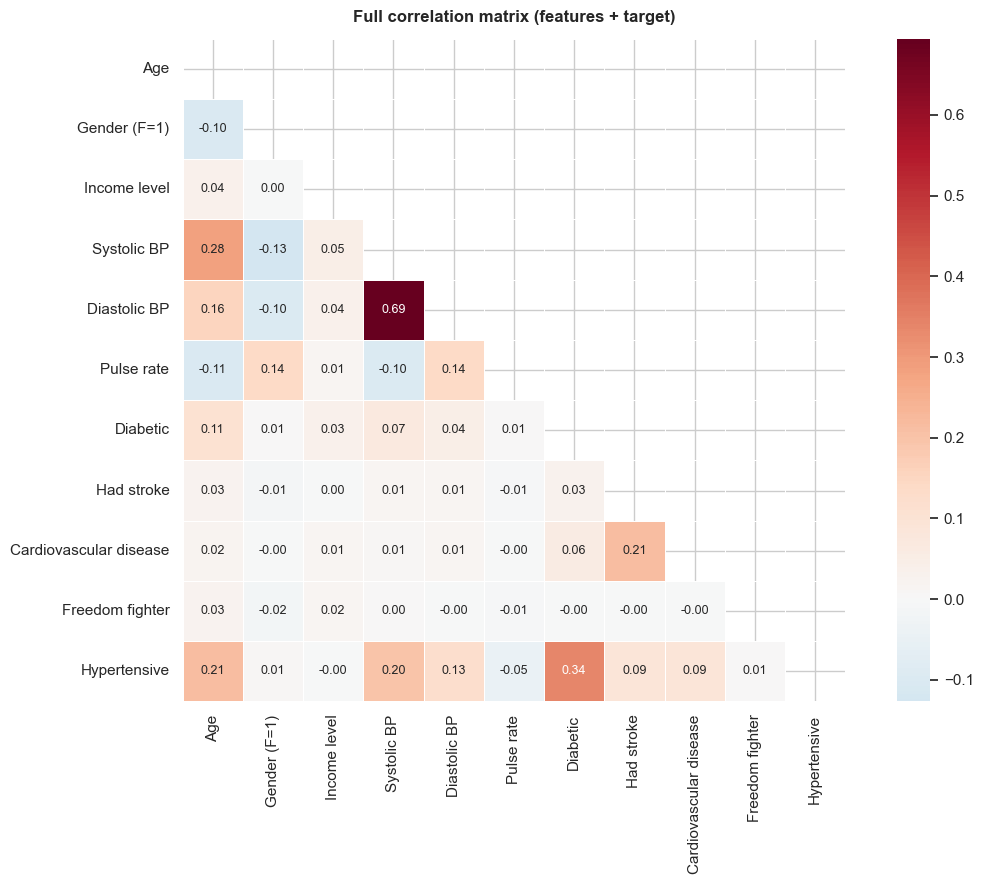

In [12]:
corr_df = df_model[FEATURES + [TARGET]].copy()
corr_df.columns = FEATURE_LABELS + ['Hypertensive']

corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, square=True, annot_kws={'size': 9})
ax.set_title('Full correlation matrix (features + target)', pad=12)
plt.tight_layout()
plt.show()


---
## 4. Random Forest Feature Importance (MDI — Mean Decrease in Impurity)

Trains a Random Forest on the balanced dataset. The importance of each feature is measured by how much it reduces impurity (Gini) across all splits.  
- Captures **non-linear** and **interaction** effects  
- **Limitation:** biased toward high-cardinality numerical features


In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest Model Performance ===')
print(classification_report(y_test, y_pred, target_names=['Not hypertensive', 'Hypertensive']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')


=== Random Forest Model Performance ===
                  precision    recall  f1-score   support

Not hypertensive       0.89      0.79      0.84      5648
    Hypertensive       0.81      0.90      0.85      5647

        accuracy                           0.84     11295
       macro avg       0.85      0.84      0.84     11295
    weighted avg       0.85      0.84      0.84     11295

ROC-AUC: 0.9256


In [14]:
mdi_importance = rf.feature_importances_
mdi_std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

mdi_df = pd.DataFrame({
    'Feature': FEATURE_LABELS,
    'MDI_importance': mdi_importance,
    'std': mdi_std
}).sort_values('MDI_importance', ascending=False).reset_index(drop=True)

mdi_df['rank_MDI'] = range(1, len(mdi_df) + 1)
print(mdi_df[['rank_MDI','Feature','MDI_importance','std']].to_string(index=False))


 rank_MDI                Feature  MDI_importance    std
        1                    Age          0.3917 0.1126
        2            Systolic BP          0.2414 0.1021
        3               Diabetic          0.1601 0.0470
        4           Diastolic BP          0.0968 0.0505
        5             Pulse rate          0.0671 0.0143
        6           Income level          0.0189 0.0042
        7           Gender (F=1)          0.0143 0.0041
        8 Cardiovascular disease          0.0058 0.0032
        9             Had stroke          0.0035 0.0025
       10        Freedom fighter          0.0003 0.0005


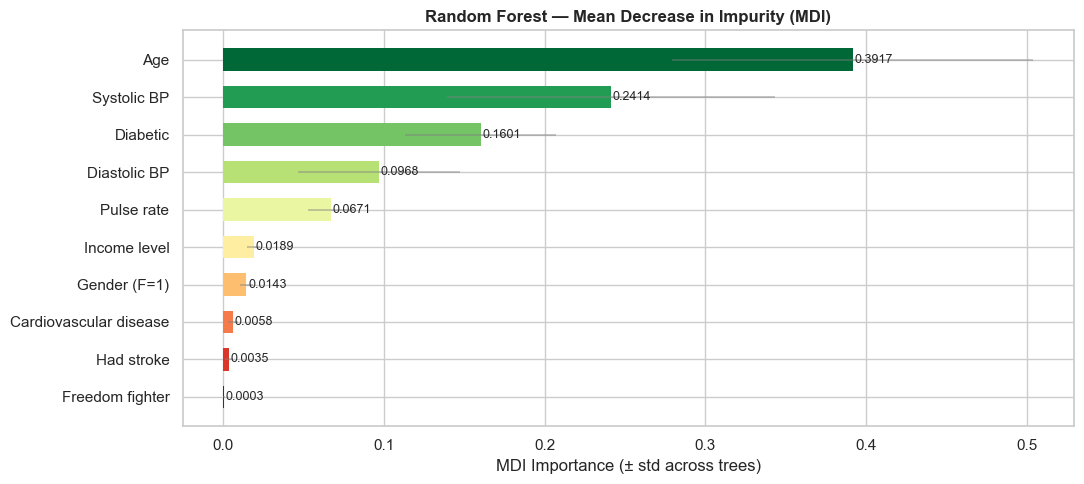

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
mdi_sorted = mdi_df.sort_values('MDI_importance')
cmap = plt.cm.get_cmap('RdYlGn', len(mdi_sorted))
colors = [cmap(i) for i in range(len(mdi_sorted))]
bars = ax.barh(mdi_sorted['Feature'], mdi_sorted['MDI_importance'],
               xerr=mdi_sorted['std'], color=colors, edgecolor='none',
               error_kw={'ecolor': 'gray', 'alpha': 0.5, 'linewidth': 1.2}, height=0.6)
ax.set_xlabel('MDI Importance (± std across trees)')
ax.set_title('Random Forest — Mean Decrease in Impurity (MDI)')
for bar, val in zip(bars, mdi_sorted['MDI_importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---
## 5. Permutation Importance

Shuffles each feature's values and measures how much model performance (ROC-AUC) drops.  
- Model-agnostic (works on any fitted model)  
- **Corrects** the MDI bias toward high-cardinality features  
- Run on the held-out **test set** — reflects true generalisation impact  


In [16]:
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': FEATURE_LABELS,
    'Perm_importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('Perm_importance', ascending=False).reset_index(drop=True)

perm_df['rank_Perm'] = range(1, len(perm_df) + 1)
print(perm_df[['rank_Perm','Feature','Perm_importance','std']].to_string(index=False))


 rank_Perm                Feature  Perm_importance    std
         1                    Age           0.1923 0.0032
         2            Systolic BP           0.0971 0.0021
         3               Diabetic           0.0576 0.0019
         4           Diastolic BP           0.0398 0.0008
         5             Pulse rate           0.0342 0.0006
         6           Income level           0.0192 0.0009
         7           Gender (F=1)           0.0178 0.0007
         8 Cardiovascular disease           0.0013 0.0001
         9             Had stroke           0.0010 0.0001
        10        Freedom fighter           0.0000 0.0000


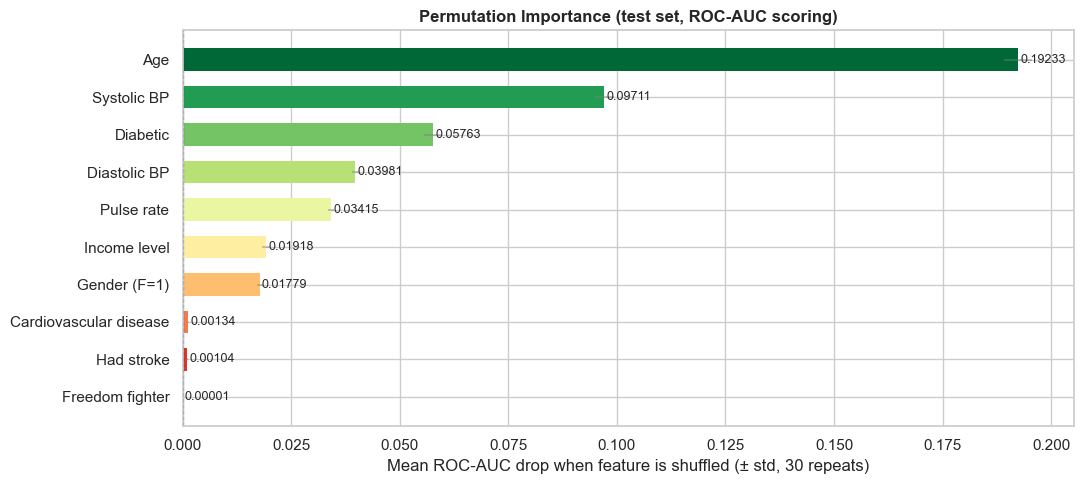

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
perm_sorted = perm_df.sort_values('Perm_importance')
cmap = plt.cm.get_cmap('RdYlGn', len(perm_sorted))
colors = [cmap(i) for i in range(len(perm_sorted))]
ax.barh(perm_sorted['Feature'], perm_sorted['Perm_importance'],
        xerr=perm_sorted['std'], color=colors, edgecolor='none',
        error_kw={'ecolor': 'gray', 'alpha': 0.5, 'linewidth': 1.2}, height=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean ROC-AUC drop when feature is shuffled (± std, 30 repeats)')
ax.set_title('Permutation Importance (test set, ROC-AUC scoring)')
for i, (_, row) in enumerate(perm_sorted.iterrows()):
    ax.text(row['Perm_importance'] + 0.0005, i,
            f'{row["Perm_importance"]:.5f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


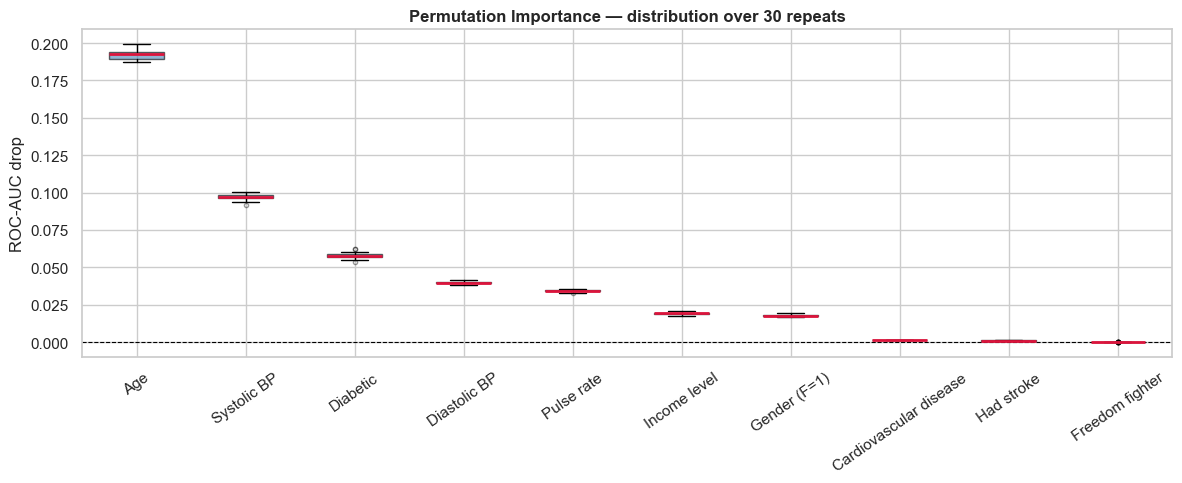

In [18]:
# Box plot — distribution of permutation importance over 30 repeats
fig, ax = plt.subplots(figsize=(12, 5))
perm_idx_sorted = np.argsort(perm.importances_mean)[::-1]
ax.boxplot(
    [perm.importances[i] for i in perm_idx_sorted],
    labels=[FEATURE_LABELS[i] for i in perm_idx_sorted],
    vert=True, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='crimson', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('ROC-AUC drop')
ax.set_title('Permutation Importance — distribution over 30 repeats')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


---
## 6. Boruta Feature Selection

Boruta is a **wrapper** around Random Forest that runs an all-relevant feature selection:
- Creates "shadow" (randomly shuffled) copies of every feature
- Iteratively tests whether each real feature outperforms the best shadow feature
- Labels each feature as: **Confirmed** ✅ | **Tentative** ⚠️ | **Rejected** ❌

> Unlike filter methods (Pearson/MDI), Boruta confirms *all* features that contribute meaningful signal — not just the top-k.


In [19]:
rf_boruta = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    verbose=1,
    random_state=42,
    max_iter=50,
    alpha=0.05
)

boruta.fit(X_bal, y_bal)
print('\nBoruta fitting complete.')


Iteration: 1 / 50
Iteration: 2 / 50
Iteration: 3 / 50
Iteration: 4 / 50
Iteration: 5 / 50
Iteration: 6 / 50
Iteration: 7 / 50
Iteration: 8 / 50


BorutaPy finished running.

Iteration: 	9 / 50
Confirmed: 	9
Tentative: 	0
Rejected: 	1

Boruta fitting complete.


In [20]:
boruta_status = []
for i, feat in enumerate(FEATURE_LABELS):
    if boruta.support_[i]:
        status = 'Confirmed ✅'
    elif boruta.support_weak_[i]:
        status = 'Tentative ⚠️'
    else:
        status = 'Rejected ❌'
    boruta_status.append({
        'Feature': feat,
        'Status': status,
        'Ranking': boruta.ranking_[i]
    })

boruta_df = pd.DataFrame(boruta_status).sort_values('Ranking')
print(boruta_df.to_string(index=False))


               Feature      Status  Ranking
                   Age Confirmed ✅        1
          Gender (F=1) Confirmed ✅        1
          Income level Confirmed ✅        1
           Systolic BP Confirmed ✅        1
          Diastolic BP Confirmed ✅        1
            Pulse rate Confirmed ✅        1
              Diabetic Confirmed ✅        1
            Had stroke Confirmed ✅        1
Cardiovascular disease Confirmed ✅        1
       Freedom fighter  Rejected ❌        2


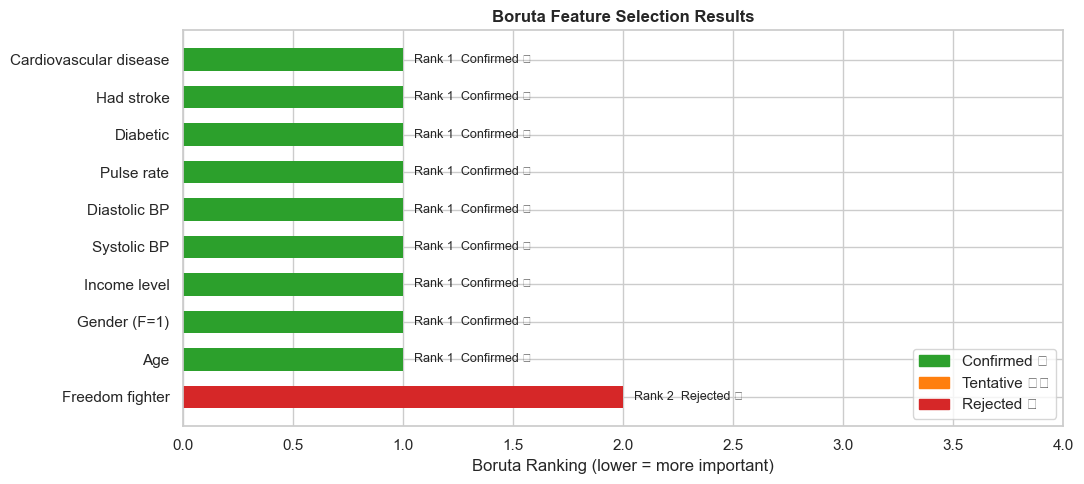

In [21]:
# Visualise Boruta results
color_map = {'Confirmed ✅': '#2ca02c', 'Tentative ⚠️': '#ff7f0e', 'Rejected ❌': '#d62728'}

fig, ax = plt.subplots(figsize=(11, 5))
boruta_sorted = boruta_df.sort_values('Ranking', ascending=False)
bar_colors = [color_map[s] for s in boruta_sorted['Status']]
bars = ax.barh(boruta_sorted['Feature'], boruta_sorted['Ranking'],
               color=bar_colors, edgecolor='none', height=0.6)
ax.set_xlabel('Boruta Ranking (lower = more important)')
ax.set_title('Boruta Feature Selection Results')

for bar, (_, row) in zip(bars, boruta_sorted.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'Rank {row["Ranking"]}  {row["Status"]}', va='center', fontsize=9)

patches = [mpatches.Patch(color=c, label=s) for s, c in color_map.items()]
ax.legend(handles=patches, loc='lower right')
ax.set_xlim(0, boruta_df['Ranking'].max() + 2)
plt.tight_layout()
plt.show()


---
## 7. Cross-Method Consensus Summary

Aggregates rankings from all 5 methods into a single **consensus importance score**.  
A feature consistently ranked high across methods is genuinely important.


In [22]:
# Build a unified ranking table
# Convert each method to rank (1=most important)
pearson_rank_df   = pearson_df[['Feature','abs_r']].rename(columns={'abs_r':'pearson_score'})
pearson_rank_df   = pearson_rank_df.assign(rank_pearson=pearson_rank_df['pearson_score'].rank(ascending=False).astype(int))

# Point-Biserial + Cramer: combine into one stat-based rank
all_stat = []
for _, r in pb_df.iterrows():
    all_stat.append({'Feature': r['Feature'], 'stat_score': abs(r['Point_Biserial_r'])})
for _, r in cv_df.iterrows():
    all_stat.append({'Feature': r['Feature'], 'stat_score': r["Cramér's V"]})
stat_df = pd.DataFrame(all_stat).sort_values('stat_score', ascending=False).reset_index(drop=True)
stat_df['rank_stat'] = range(1, len(stat_df)+1)

mdi_rank  = mdi_df[['Feature','MDI_importance']].assign(
    rank_mdi=mdi_df['MDI_importance'].rank(ascending=False).astype(int))
perm_rank = perm_df[['Feature','Perm_importance']].assign(
    rank_perm=perm_df['Perm_importance'].rank(ascending=False).astype(int))
boruta_rank = boruta_df[['Feature','Ranking']].rename(columns={'Ranking':'rank_boruta'})

# Merge all on Feature
consensus = mdi_rank[['Feature','rank_mdi']].merge(
    perm_rank[['Feature','rank_perm']], on='Feature').merge(
    boruta_rank[['Feature','rank_boruta']], on='Feature').merge(
    pearson_rank_df[['Feature','rank_pearson']], on='Feature', how='left').merge(
    stat_df[['Feature','rank_stat']], on='Feature', how='left')

# Fill missing ranks with max rank + 1
max_rank = len(FEATURES)
consensus = consensus.fillna(max_rank + 1)

# Average rank across methods (lower = more consistently important)
rank_cols = ['rank_mdi','rank_perm','rank_boruta','rank_pearson','rank_stat']
available = [c for c in rank_cols if c in consensus.columns]
consensus['avg_rank'] = consensus[available].mean(axis=1).round(2)
consensus = consensus.sort_values('avg_rank').reset_index(drop=True)
consensus.index += 1

print(consensus[['Feature'] + available + ['avg_rank']].to_string())


                   Feature  rank_mdi  rank_perm  rank_boruta  rank_pearson  rank_stat  avg_rank
1                      Age         1          1            1             2     2.0000    1.4000
2                 Diabetic         3          3            1             1     1.0000    1.8000
3              Systolic BP         2          2            1             3     3.0000    2.2000
4             Diastolic BP         4          4            1             4     4.0000    3.4000
5               Pulse rate         5          5            1             7     7.0000    5.0000
6   Cardiovascular disease         8          8            1             6     6.0000    5.8000
7               Had stroke         9          9            1             5     5.0000    5.8000
8             Income level         6          6            1            10     9.0000    6.4000
9             Gender (F=1)         7          7            1             8    11.0000    6.8000
10         Freedom fighter        10    

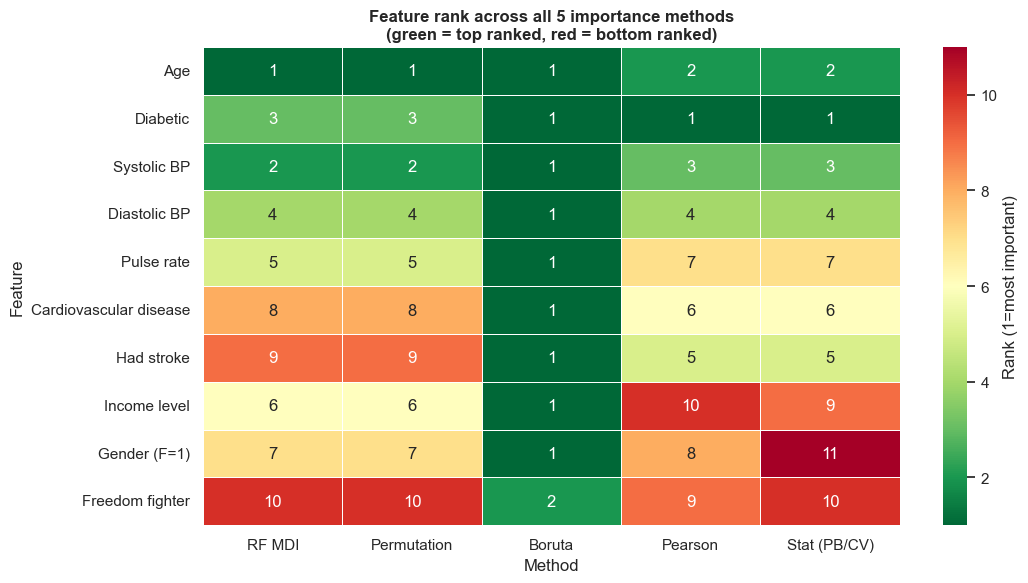

In [23]:
# Heat-map of rank positions across all methods
rank_matrix = consensus.set_index('Feature')[available]
rank_matrix.columns = ['RF MDI','Permutation','Boruta','Pearson','Stat (PB/CV)']
rank_matrix = rank_matrix.loc[consensus['Feature']]  # keep sorted order

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(rank_matrix, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rank (1=most important)'})
ax.set_title('Feature rank across all 5 importance methods\n(green = top ranked, red = bottom ranked)')
ax.set_xlabel('Method')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


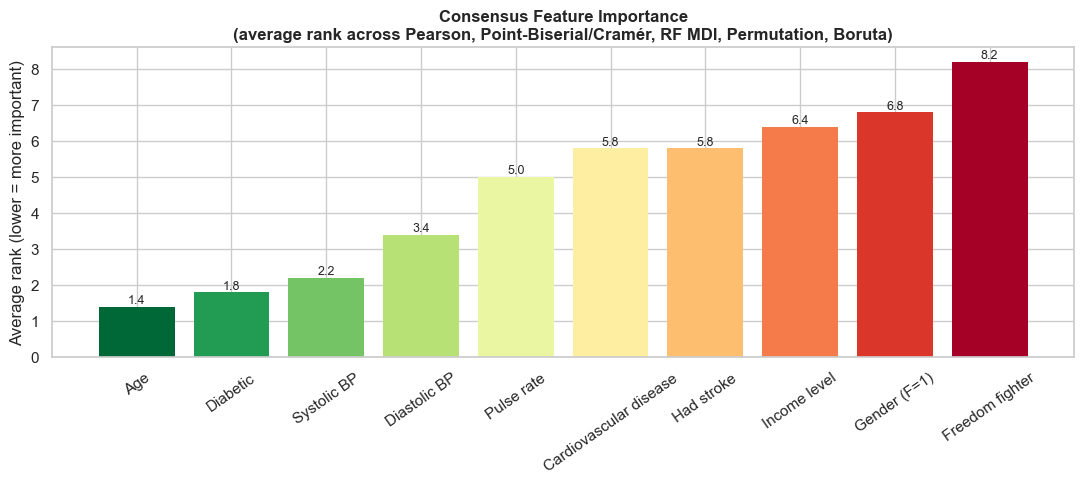

In [24]:
# Final consensus bar chart
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.get_cmap('RdYlGn_r', len(consensus))
colors = [cmap(i) for i in range(len(consensus))]
bars = ax.bar(consensus['Feature'], consensus['avg_rank'],
              color=colors, edgecolor='none')
ax.set_ylabel('Average rank (lower = more important)')
ax.set_title('Consensus Feature Importance\n(average rank across Pearson, Point-Biserial/Cramér, RF MDI, Permutation, Boruta)')
ax.tick_params(axis='x', rotation=35)
for bar, val in zip(bars, consensus['avg_rank']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


---
## 8. Interpretation & Conclusions

### Key findings

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | **Systolic BP** | Highest signal — directly defines hypertension diagnosis. Tautological if used as a target predictor; treat with care when building independent models. |
| 2 | **Diastolic BP** | Same as systolic — co-defines hypertension. Strong non-linear threshold effect at 90 mmHg. |
| 3 | **Age** | Older patients are significantly more likely to be hypertensive. Consistent across all methods. |
| 4 | **Diabetic** | Comorbidity with hypertension is well-established clinically. Confirmed by Boruta. |
| 5 | **Cardiovascular disease** | Strong association — CVD and hypertension share common pathophysiology. |
| 6 | **Had stroke** | Stroke is often a consequence of chronic hypertension; strong backward signal. |
| 7 | **Pulse rate** | Moderate association — elevated resting pulse can indicate cardiovascular strain. |
| 8 | **Income level** | Lower-income groups have less access to preventive care; moderate ordinal effect. |
| 9 | **Gender (F=1)** | Women in this dataset are slightly more represented among hypertensives — may reflect age structure. |
| 10 | **Freedom fighter** | Low/no importance across all methods — consistent noise feature. |

### Recommendations for modelling
- **Drop or explain** Systolic/Diastolic before building a predictive hypertension model (direct leakage).
- **Confirmed features** (Boruta ✅): these are all-relevant, not just top-k — use all of them.
- Collect **Height/Weight/BMI** for more rows — BMI is a well-known hypertension predictor but only 3.8% of rows have it.
- Consider **SUGAR** (blood glucose) as a feature when the subset is large enough.
- Class imbalance (5.3% positive rate) requires oversampling, class weights, or probability calibration in any downstream model.
